In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# 데이터 불러오기
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)

# 입력과 타깃 나누기
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

# 데이터셋 클래스 정의
class AbaloneDataset(Dataset):
    def __init__(self, input_data, target_data):
        self.input_data = input_data
        self.target_data = target_data

    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, index):
        input_tensor = torch.tensor(self.input_data[index])
        target_tensor = torch.tensor(self.target_data[index])

        return input_tensor, target_tensor

# 학습/검증/테스트 분할
train_size = int(len(input_data) * 0.8)
val_size = int(len(input_data) * 0.1)

train_inputs = input_data[:train_size]
train_targets = target_data[:train_size]

val_inputs = input_data[train_size:train_size + val_size]
val_targets = target_data[train_size:train_size + val_size]

test_inputs = input_data[train_size + val_size:]
test_targets = target_data[train_size + val_size:]

# 표준화
scaler = StandardScaler()
scaler.fit(train_inputs)

train_inputs_scaled = scaler.transform(train_inputs)
val_inputs_scaled = scaler.transform(val_inputs)
test_inputs_scaled = scaler.transform(test_inputs)

# 데이터셋 만들기
train_dataset = AbaloneDataset(train_inputs_scaled, train_targets)
val_dataset = AbaloneDataset(val_inputs_scaled, val_targets)
test_dataset = AbaloneDataset(test_inputs_scaled, test_targets)

# 데이터로더 만들기
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32)

In [ ]:
# 모델 클래스 정의
class AbaloneModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(7, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x


# 모델, 손실 함수, 옵티마이저 객체 만들기
model = AbaloneModel()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# training loop
epochs = 10
step = 0
for epoch in range(epochs):
    model.train()
    for train_batch in train_dataloader:
        x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)
        pred = model(x_train).squeeze()
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1

        if step % 100 == 0:
            print(f'step {step}, train loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        losses = []
        for val_batch in val_dataloader:
            x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
            pred = model(x_val).squeeze()
            loss = loss_fn(pred, y_val)
            losses.append(loss.item())

        val_loss_avg = sum(losses) / len(losses)
        print(f'epoch {epoch+1}/{epochs}, validation loss: {val_loss_avg:.4f}\n')

epoch 1/10, validation loss: 24.3773

step 100, train loss: 39.6749
epoch 2/10, validation loss: 9.1218

step 200, train loss: 31.4877
epoch 3/10, validation loss: 8.7852

step 300, train loss: 26.1149
epoch 4/10, validation loss: 6.0316

step 400, train loss: 9.7953
epoch 5/10, validation loss: 6.2487

epoch 6/10, validation loss: 5.9834

step 500, train loss: 13.9838
epoch 7/10, validation loss: 4.9699

step 600, train loss: 21.2990
epoch 8/10, validation loss: 5.2776

step 700, train loss: 5.9011
epoch 9/10, validation loss: 5.0121

step 800, train loss: 15.4511
epoch 10/10, validation loss: 5.7337



In [ ]:
model.eval()
with torch.no_grad():
    losses = []
    preds = []
    targets = []
    for test_batch in test_dataloader: #train_dataloader -> test_dataloader
        x_test, y_test = test_batch[0].to(device), test_batch[1].to(device)
        pred = model(x_test).squeeze()
        loss = loss_fn(pred, y_test)
        losses.append(loss.item())

        preds.extend(pred.cpu().numpy())
        targets.extend(y_test.cpu().numpy())

    test_loss_avg = sum(losses) / len(losses)
    print(f'test loss: {test_loss_avg:.4f}\n')

test loss: 8.6118



In [ ]:
print(f'val RMSE : {np.sqrt(val_loss_avg) : .4f}')
print(f'test RMSE : {np.sqrt(test_loss_avg) : .4f}')

val RMSE :  2.3945
test RMSE :  2.9346


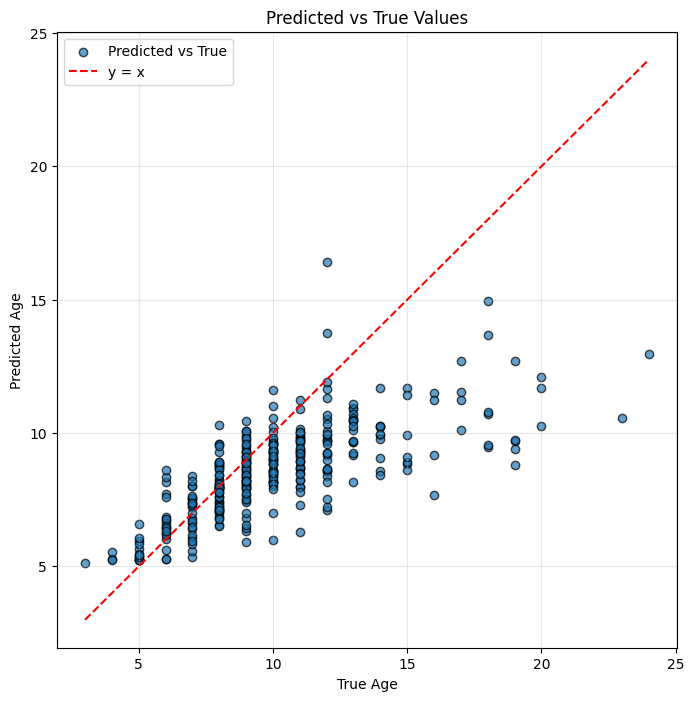

In [ ]:
import matplotlib.pyplot as plt

# 산점도 그리기
plt.figure(figsize=(8, 8))
plt.scatter(targets, preds, alpha=0.7, label='Predicted vs True', edgecolor='k')

# 비교를 위한 y = x 직선 그리기
min_val = min(min(targets), min(preds))
max_val = max(max(targets), max(preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# 레이블 및 범례
plt.title('Predicted vs True Values')
plt.xlabel('True Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(alpha=0.3)
plt.show()